In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [2]:
TINY_IMAGENET_ROOT = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200"


class TinyImageNetMAE(Dataset):
    def __init__(self, root=TINY_IMAGENET_ROOT, img_size=224, split="train", verify=True):
        self.root = Path(root)
        self.img_size = img_size
        self.paths = []
        split_dir = self.root / split
        if not split_dir.exists():
            raise FileNotFoundError(f"Split folder not found: {split_dir}")
        for c in split_dir.iterdir():
            if c.is_dir():
                imgs_dir = c / "images"
                files_iter = imgs_dir.iterdir() if imgs_dir.exists() else c.iterdir()
                for f in files_iter:
                    if f.suffix.lower() in (".jpg", ".jpeg", ".png"):
                        self.paths.append(str(f))
        if verify:
            self._verify()

    def _verify(self):
        n = len(self.paths)
        print(f"[TinyImageNetMAE] root: {self.root}")
        print(f"[TinyImageNetMAE] images: {n}")
        if n == 0:
            raise FileNotFoundError(f"No images under {self.root}")
        img = Image.open(self.paths[0]).convert("RGB")
        print(f"[TinyImageNetMAE] sample shape OK: {np.array(img).shape}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        img = np.array(img)
        img = Image.fromarray(img).resize((self.img_size, self.img_size))
        img = np.array(img) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = (img - mean) / std
        return torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)

train_ds = TinyImageNetMAE(split="train")
print(f"Train size: {len(train_ds)}")

[TinyImageNetMAE] root: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
[TinyImageNetMAE] images: 100000
[TinyImageNetMAE] sample shape OK: (64, 64, 3)
Train size: 100000


In [3]:
def patchify(imgs, patch_size=16):
    """(B, C, H, W) -> (B, num_patches, patch_dim)"""
    B, C, H, W = imgs.shape
    assert H % patch_size == 0 and W % patch_size == 0
    num_h, num_w = H // patch_size, W // patch_size
    patches = imgs.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    patches = patches.contiguous().view(B, C, -1, patch_size, patch_size)
    patches = patches.permute(0, 2, 1, 3, 4).contiguous().view(B, num_h * num_w, -1)
    return patches

def unpatchify(patches, patch_size=16, C=3, H=224, W=224):
    """(B, num_patches, patch_dim) -> (B, C, H, W)"""
    B, N, _ = patches.shape
    num_h, num_w = H // patch_size, W // patch_size
    patches = patches.view(B, num_h, num_w, C, patch_size, patch_size)
    img = patches.permute(0, 3, 1, 4, 2, 5).contiguous().view(B, C, H, W)
    return img

def random_masking(x, mask_ratio=0.75):
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))
    noise = torch.rand(B, N, device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :len_keep]
    x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))
    return x_masked, ids_restore, ids_keep

In [4]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=12, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
        )

    def forward(self, x):
        h, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + h
        return x + self.mlp(self.norm2(x))

class MAEEncoder(nn.Module):
    def __init__(self, num_patches=196, patch_dim=768, embed_dim=768, depth=12, heads=12):
        super().__init__()
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, ids_keep):
        B = x.size(0)
        x = self.patch_embed(x)
        pos = torch.gather(self.pos_embed.expand(B, -1, -1), 1, ids_keep.unsqueeze(-1).expand(-1, -1, x.size(-1)))
        x = x + pos
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)

In [5]:
class MAEDecoder(nn.Module):
    def __init__(self, num_patches=196, enc_dim=768, dec_dim=384, patch_dim=768, depth=12, heads=6):
        super().__init__()
        self.decoder_embed = nn.Linear(enc_dim, dec_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches, dec_dim))
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)
        self.blocks = nn.ModuleList([TransformerBlock(dec_dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dec_dim)
        self.decoder_pred = nn.Linear(dec_dim, patch_dim)

    def forward(self, x, ids_restore):
        x = self.decoder_embed(x)
        num_masked = ids_restore.size(1) - x.size(1)
        mask_tokens = self.mask_token.repeat(x.size(0), num_masked, 1)
        x_ = torch.cat([x, mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, x_.size(-1)))
        x = x_ + self.decoder_pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return self.decoder_pred(x)

In [6]:
class MAE(nn.Module):
    def __init__(self, img_size=224, patch_size=16, enc_dim=768, dec_dim=384, enc_depth=12, dec_depth=12,
                 enc_heads=12, dec_heads=6, mask_ratio=0.75):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_dim = 3 * patch_size * patch_size

        self.encoder = MAEEncoder(self.num_patches, self.patch_dim, enc_dim, enc_depth, enc_heads)
        self.decoder = MAEDecoder(self.num_patches, enc_dim, dec_dim, self.patch_dim, dec_depth, dec_heads)

    def forward(self, imgs):
        B, C, H, W = imgs.shape
        patches = patchify(imgs, self.patch_size)
        x_masked, ids_restore, ids_keep = random_masking(patches, self.mask_ratio)

        latent = self.encoder(x_masked, ids_keep)
        pred = self.decoder(latent, ids_restore)

        target = patches
        mask = torch.ones(B, self.num_patches, device=imgs.device)
        mask = torch.scatter(mask, 1, ids_keep, 0)
        loss = ((pred - target) ** 2).mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum().clamp(min=1)
        return loss, pred, mask, ids_restore

In [14]:
from torch.utils.data import Subset

SUBSET_SIZE = 20000
train_ds_small = Subset(train_ds, range(SUBSET_SIZE))
BATCH_SIZE = 64
NUM_WORKERS = 2
train_loader = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
model = MAE(img_size=224, patch_size=16, enc_dim=768, dec_dim=384, enc_depth=12, dec_depth=12,
            enc_heads=12, dec_heads=6, mask_ratio=0.75).to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params / 1e6:.2f}M")

Total parameters: 107.76M


In [9]:
# Quick test: one batch
batch = next(iter(train_loader))
print("Batch shape:", batch.shape)
batch = batch.to(device)
with torch.no_grad():
    loss, _, _, _ = model(batch)
print("Loss (no grad):", loss.mean().item())

Batch shape: torch.Size([64, 3, 224, 224])
Loss (no grad): 0.9608359336853027


In [15]:
NUM_EPOCHS = 30
optimizer = torch.optim.AdamW(model.parameters(), lr=1.5e-4, weight_decay=0.05, betas=(0.9, 0.95))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = torch.amp.GradScaler('cuda')

history = []
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss, _, _, _ = model(batch)
        loss = loss.mean()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * batch.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    history.append(epoch_loss)
    scheduler.step()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} Loss: {epoch_loss:.4f}")
print("Training done.")

Epoch 1/30 Loss: 1.0794
Epoch 2/30 Loss: 1.0094
Epoch 3/30 Loss: 0.9850
Epoch 4/30 Loss: 0.9729
Epoch 5/30 Loss: 0.9476
Epoch 6/30 Loss: 0.8883
Epoch 7/30 Loss: 0.8403
Epoch 8/30 Loss: 0.8216
Epoch 9/30 Loss: 0.7943
Epoch 10/30 Loss: 0.7757
Epoch 11/30 Loss: 0.7506
Epoch 12/30 Loss: 0.6603
Epoch 13/30 Loss: 0.6011
Epoch 14/30 Loss: 0.5683
Epoch 15/30 Loss: 0.5300
Epoch 17/30 Loss: 0.4944
Epoch 18/30 Loss: 0.4849
Epoch 19/30 Loss: 0.4661
Epoch 20/30 Loss: 0.4534
Epoch 21/30 Loss: 0.4451
Epoch 22/30 Loss: 0.4355
Epoch 23/30 Loss: 0.4258
Epoch 24/30 Loss: 0.4200
Epoch 25/30 Loss: 0.4148
Epoch 26/30 Loss: 0.4100
Epoch 27/30 Loss: 0.4071
Epoch 28/30 Loss: 0.4035
Epoch 29/30 Loss: 0.4033
Epoch 30/30 Loss: 0.4025
Training done.


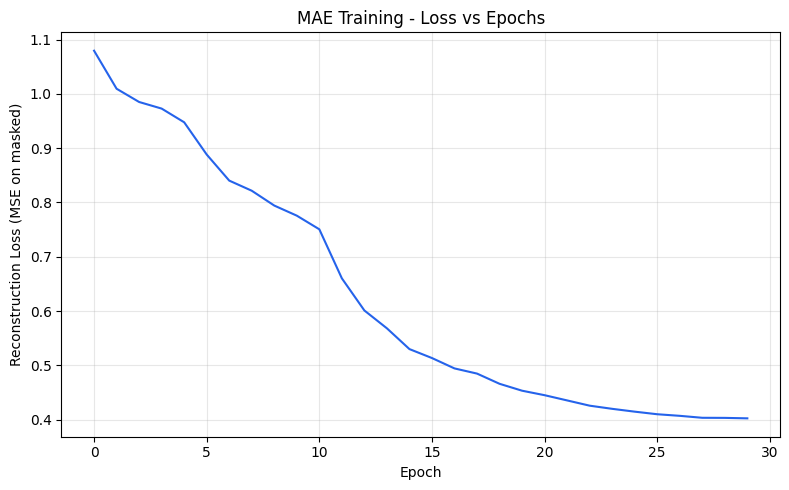

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history, color='#2563eb')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (MSE on masked)')
plt.title('MAE Training - Loss vs Epochs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

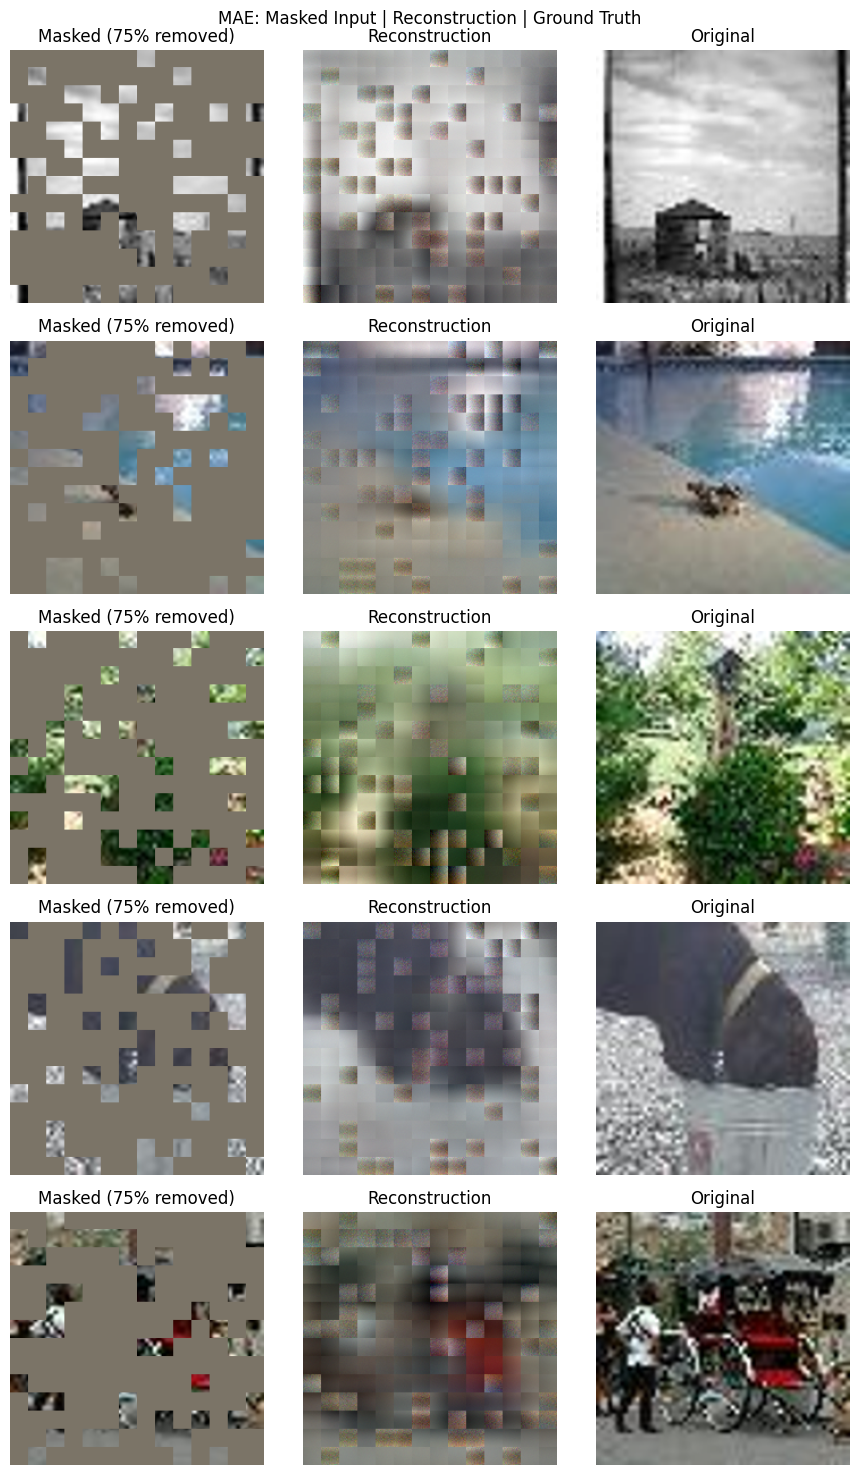

In [17]:
def denorm(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
    return x * std + mean

model.eval()
num_show = 5
loader_iter = iter(DataLoader(train_ds, batch_size=num_show, shuffle=True))
batch = next(loader_iter).to(device)

with torch.no_grad():
    _, pred, mask, _ = model(batch)
    patches = patchify(batch, 16)
    masked_patches = patches * (1 - mask).unsqueeze(-1)
    masked_img = unpatchify(masked_patches, 16, 3, 224, 224)
    rec = unpatchify(pred, 16, 3, 224, 224)

orig = denorm(batch).clamp(0, 1).cpu()
rec = denorm(rec).clamp(0, 1).cpu()
masked_img = denorm(masked_img).clamp(0, 1).cpu()

fig, axes = plt.subplots(num_show, 3, figsize=(9, 3*num_show))
for i in range(num_show):
    axes[i, 0].imshow(masked_img[i].permute(1, 2, 0))
    axes[i, 0].set_title('Masked (75% removed)')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(rec[i].permute(1, 2, 0))
    axes[i, 1].set_title('Reconstruction')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(orig[i].permute(1, 2, 0))
    axes[i, 2].set_title('Original')
    axes[i, 2].axis('off')
plt.suptitle('MAE: Masked Input | Reconstruction | Ground Truth')
plt.tight_layout()
plt.show()

In [18]:
def psnr(img1, img2, max_val=1.0):
    mse = ((img1 - img2) ** 2).mean()
    if mse == 0:
        return 100.0
    return 20 * math.log10(max_val / math.sqrt(mse.item()))

def ssim_1d(x, y, C1=0.01**2, C2=0.03**2):
    mu_x, mu_y = x.mean(), y.mean()
    sig_x2 = ((x - mu_x)**2).mean()
    sig_y2 = ((y - mu_y)**2).mean()
    sig_xy = ((x - mu_x) * (y - mu_y)).mean()
    return ((2*mu_x*mu_y + C1)*(2*sig_xy + C2)) / ((mu_x**2 + mu_y**2 + C1)*(sig_x2 + sig_y2 + C2))

def ssim(img1, img2):
    """Simple SSIM over full image (single scale)."""
    c1, c2 = 0.01**2, 0.03**2
    mu1 = img1.mean(dim=(1,2))
    mu2 = img2.mean(dim=(1,2))
    mu1_sq = mu1**2
    mu2_sq = mu2**2
    mu12 = (img1 * img2).mean(dim=(1,2))
    sig1_sq = (img1**2).mean(dim=(1,2)) - mu1_sq
    sig2_sq = (img2**2).mean(dim=(1,2)) - mu2_sq
    sig12 = (img1 * img2).mean(dim=(1,2)) - mu1*mu2
    s = (2*mu12 + c1)*(2*sig12 + c2) / ((mu1_sq + mu2_sq + c1)*(sig1_sq + sig2_sq + c2))
    return s.mean().item()

model.eval()
psnr_list, ssim_list = [], []
with torch.no_grad():
    for idx, batch in enumerate(DataLoader(train_ds, batch_size=1, shuffle=True)):
        if idx >= 5:
            break
        batch = batch.to(device)
        _, pred, _, ids_restore = model(batch)
        rec = unpatchify(pred, 16, 3, 224, 224)
        o = denorm(batch).clamp(0, 1).cpu()
        r = denorm(rec).clamp(0, 1).cpu()
        psnr_list.append(psnr(o, r))
        ssim_list.append(ssim(o, r))

print("Sample | PSNR (dB) | SSIM")
print("-" * 30)
for i in range(5):
    print(f"  {i+1}   |   {psnr_list[i]:.2f}    | {ssim_list[i]:.4f}")
print(f"\nMean PSNR: {np.mean(psnr_list):.2f} dB")
print(f"Mean SSIM: {np.mean(ssim_list):.4f}")

Sample | PSNR (dB) | SSIM
------------------------------
  1   |   16.52    | 0.5968
  2   |   13.51    | 0.6060
  3   |   18.31    | 0.8660
  4   |   18.65    | 0.9129
  5   |   14.44    | 0.4530

Mean PSNR: 16.29 dB
Mean SSIM: 0.6869


In [19]:
save_path = "/kaggle/working/mae_tinyimagenet.pt"
torch.save(model.module.state_dict() if hasattr(model, 'module') else model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /kaggle/working/mae_tinyimagenet.pt


In [20]:
import gradio as gr
import numpy as np
from PIL import Image

def denorm_app(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
    return (x * std + mean).clamp(0, 1)

def run_mae_ui(img, mask_ratio):
    if img is None:
        return None, None, None
    mask_ratio = max(0.1, min(0.95, float(mask_ratio)))
    # preprocess
    img = Image.fromarray(img).resize((224, 224))
    img = np.array(img) / 255.0
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    x = torch.tensor((img - mean) / std, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
    # forward
    m = model.module if hasattr(model, 'module') else model
    with torch.no_grad():
        patches = patchify(x, 16)
        x_masked, ids_restore, ids_keep = random_masking(patches, mask_ratio)
        latent = m.encoder(x_masked, ids_keep)
        pred = m.decoder(latent, ids_restore)
    rec = unpatchify(pred, 16, 3, 224, 224)
    mask = torch.ones(1, 196, device=x.device)
    mask = torch.scatter(mask, 1, ids_keep, 0)
    masked_patches = patches * (1 - mask).unsqueeze(-1)
    masked_img = unpatchify(masked_patches, 16, 3, 224, 224)
    # to numpy for display
    orig = denorm_app(x).cpu().squeeze(0).permute(1, 2, 0).numpy()
    rec_np = denorm_app(rec).cpu().squeeze(0).permute(1, 2, 0).numpy()
    masked_np = denorm_app(masked_img).cpu().squeeze(0).permute(1, 2, 0).numpy()
    return masked_np, rec_np, orig

with gr.Blocks(title="MAE Reconstruction") as app:
    gr.Markdown("# Masked Autoencoder (MAE) - Image Reconstruction")
    with gr.Row():
        inp_img = gr.Image(label="Upload image", type="numpy")
        mask_slider = gr.Slider(0.1, 0.95, value=0.75, step=0.05, label="Mask ratio (fraction masked)")
    btn = gr.Button("Reconstruct")
    with gr.Row():
        out_masked = gr.Image(label="Masked input")
        out_rec = gr.Image(label="Reconstruction")
        out_orig = gr.Image(label="Original")
    btn.click(fn=run_mae_ui, inputs=[inp_img, mask_slider], outputs=[out_masked, out_rec, out_orig])

app.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://a616faebc665454944.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
